# How to use:
<br>
This is the notebook that allows you grab data to move into the hard-code data.py.<br>
What this means is - to avoid long download times - downloads can be done beforehand then stored appropriatley.<br>
The notebook will return two arrays. <br>
The first array is the CHIRPS v-2.0 obs data. <br>
The second array is the ECMWF monthly statistcs Hindcast data. - it is ordered in years doing down the rows. And members going along the collumn. It is cut off at member 15. <br>
<br>
To move these to data.py just copy and paste the output and label the name appropriatley following the guidance in the commented seciton of that python file. <br>
<br>
To use this notebooks to download the data you must :<br>
1. set the location as you would normally type it in the 1st cell ie: 'Uganda' or 'South Sudan' <br>
2. Set the area to an approximate area bounds of the country in question - Ideally a little larger than it ie: for Uganda "area": [5.0,25.0,-5.0,35.0] and "area_str": "5.0:25.0:-5.0,35.0"<br>
Run all cells up to the break to completion. 

In [2]:
location = 'Algeria' # not yet done

In [ ]:
import os
import requests
import cdsapi
from concurrent.futures import ThreadPoolExecutor



# Configuration variables
CONFIG = {
    "centre": "ecmwf",
    "system": "51",
    "month": 10,
    "leadtime_month": [2, 3, 4],
    "area": [37.0,-10.0,17.5,11.0], #N,W,S,E [Kenya - [5.0, 34.0, -5.0, 42.0] , Sudan - [25.0,20.0,5.0,40.0], South_Sudan -[15.0,20.0,0.0,40.0] egypt-  31.8, 24.0, 21.9, 37.3
    "area_str": "37.0:-10.0:17.5:11.0",     # Uganda - [5.0,25.0,-5.0,35.0]
    "variable": "total_precipitation",
    "obs_variable": "total_precipitation",
    "hcstarty": 1993,
    "hcendy": 2017,
    "downloaddir": "data_down",
    "years": [str(y) for y in range(1993, 2017)]
}
leads_str = "".join(map(str, CONFIG["leadtime_month"]))
Name = f"{CONFIG['centre']}_{CONFIG['system']}_{CONFIG['years'][0]}-{CONFIG['years'][-1]}_monthly_mean_{CONFIG['month']}_{leads_str}_{CONFIG['area_str']}_{CONFIG['variable']}.grib"

os.makedirs(CONFIG["downloaddir"], exist_ok=True)

def do_cdsapi_call():
    """Download seasonal monthly single-level data from CDSAPI."""
    c = cdsapi.Client()
    leads_str = "".join(map(str, CONFIG["leadtime_month"]))
    fname = os.path.join(
        CONFIG["downloaddir"],
        f"{CONFIG['centre']}_{CONFIG['system']}_{CONFIG['years'][0]}-{CONFIG['years'][-1]}_monthly_mean_{CONFIG['month']}_{leads_str}_{CONFIG['area_str']}_{CONFIG['variable']}.grib"
    )

    if os.path.exists(fname):
        print(f'File {fname} already exists')
        return

    c.retrieve(
        "seasonal-monthly-single-levels",
        {
            "format": "grib",
            "originating_centre": CONFIG["centre"],
            "system": CONFIG["system"],
            "variable": [CONFIG["variable"]],
            "product_type": "monthly_mean",
            "year": CONFIG["years"],
            "month": f"{CONFIG['month']:02d}",
            "leadtime_month": CONFIG["leadtime_month"],
            "area": CONFIG["area"],
        },
        fname,
    )

def get_obs():
    """Download ERA5 reanalysis data from CDSAPI."""
    c = cdsapi.Client()
    obs_fname = os.path.join(
        CONFIG["downloaddir"],
        f"era5_{CONFIG['obs_variable']}_{CONFIG['hcstarty']}-{CONFIG['hcendy']}_monthly_{CONFIG['area_str']}.grib"
    )

    if os.path.exists(obs_fname):
        print(f'File {obs_fname} already exists')
        return obs_fname

    months = [
        f"{(CONFIG['month'] + leadm) % 12 or 12:02d}"
        for leadm in CONFIG["leadtime_month"]
    ]

    c.retrieve(
        'reanalysis-era5-single-levels-monthly-means',
        {
            'product_type': 'monthly_averaged_reanalysis',
            "variable": [CONFIG["obs_variable"]],
            'year': [str(yy) for yy in range(CONFIG["hcstarty"], CONFIG["hcendy"] + 2)],
            'month': months,
            'time': '00:00',
            'grid': '1/1',
            'area': CONFIG["area"],
            'format': 'grib',
        },
        obs_fname
    )
    return obs_fname

def download_chirps_data():
    """Download CHIRPS monthly data for specified years."""
    base_url = "https://data.chc.ucsb.edu/products/CHIRPS/v3.0/monthly/global/netcdf/by_year/" #https://data.chc.ucsb.edu/products/CHIRPS/v3.0/monthly/global/netcdf/by_year/
                                                                         # https://data.chc.ucsb.edu/products/CHIRPS/v3.0/monthly/global/netcdf/by_year/chirps-v3.0.1981.monthly.nc
    def download_file(year):
        file_name = f"chirps-v3.0.{year}.monthly.nc"
        url = f"{base_url}/{file_name}"
        output_path = os.path.join(CONFIG["downloaddir"], file_name)

        if os.path.exists(output_path):
            print(f"{file_name} already exists. Skipping...")
            return

        try:
            print(f"Downloading {file_name}...")
            response = requests.get(url, timeout=60)
            response.raise_for_status()
            with open(output_path, 'wb') as f:
                f.write(response.content)
            print(f"{file_name} download complete.")
        except requests.RequestException as e:
            print(f"Failed to download {file_name}: {e}")

    with ThreadPoolExecutor(max_workers=5) as executor:
        executor.map(download_file, range(CONFIG["hcstarty"], CONFIG["hcendy"] + 1))

def run_full_download_pipeline():
    """Run the full pipeline for downloading climate data."""
    do_cdsapi_call()
    #get_obs()
    download_chirps_data()

# Execute the pipeline
run_full_download_pipeline()


The next cell arranges the CHIRPS OBS data too be in the correct manner for DATA.py

In [ ]:
# import numpy as np
# import xarray as xr
# import geopandas as gpd
# import rioxarray
# import cartopy.io.shapereader as shpreader
# from shapely.geometry import mapping
# import os
# import shutil

# # Load Kenya polygon from Natural Earth shapefile
# country_set = "admin_0_countries"
# shapefile_path = shpreader.natural_earth(resolution="10m", category="cultural", name=country_set)

# # Ensure shapefile components are copied to local directory
# if not os.path.exists('ecmwf'):
#     os.makedirs('ecmwf')

# for ext in [".shp", ".shx", ".dbf", ".prj", ".cpg"]:
#     source_file = str(shapefile_path).replace(".shp", ext)
#     shutil.copy(source_file, os.path.join('ecmwf', os.path.basename(source_file)))

# # Load country polygons and filter for Kenya
# geodf = gpd.read_file("ecmwf/ne_10m_admin_0_countries.shp")
# kenya_geom = geodf[geodf['ADMIN'] == location]

# # Define OND months and years of interest
# ond_months = [10, 11, 12]
# years = range(1993, 2017)

# # Dictionary to store average daily precipitation for OND per year
# average_daily_precip = {}

# for year in years:
#     file_name = f"data_down/chirps-v3.0.{year}.monthly.nc"
#     print("processing...")
#     ds = xr.open_dataset(file_name)
#     #print(ds)
    
#     # Write CRS to the 'precip' variable
#     precip = ds['precip']
#     precip = precip.rio.write_crs("EPSG:4326")
    
#     # Clip using Kenya polygon
#     clipped = precip.rio.clip(kenya_geom.geometry.apply(mapping), kenya_geom.crs, drop=False, invert=False)
#     #print(clipped)
    
#     # Select OND months
#     ond_data = clipped.sel(time=clipped.time.dt.month.isin(ond_months))
    
#     def nan_sum_with_nan_if_all_nan(x, dim):
#         return xr.where(x.isnull().all(dim), np.nan, x.sum(dim=dim, skipna=True))

#     # Apply to your data
#     total_precip = nan_sum_with_nan_if_all_nan(ond_data, dim='time')


    
#     # Calculate the mean precipitation over the region
#     mean_precip = total_precip.mean(skipna=True).item()
    
#     # Calculate average daily precipitation (92 days in OND) - Chirps is in mm/time_step so mm/month. 
#     avg_daily_precip = mean_precip / 92
    
#     # Store the result
#     average_daily_precip[year] = round(avg_daily_precip, 2)
#     print("complete",year)


# # Extract and print only the values
# precip_values = list(average_daily_precip.values())
# print("OND average daily precipitation values (mm/day):")
# print("Chirps_"+location, "=",precip_values)


In [123]:
import numpy as np
import xarray as xr
import geopandas as gpd
import rioxarray
import cartopy.io.shapereader as shpreader
from shapely.geometry import mapping
import os
import shutil

# Define location
#location = "Iraq"

# Load Kenya polygon from Natural Earth shapefile
country_set = "admin_0_countries"
shapefile_path = shpreader.natural_earth(resolution="10m", category="cultural", name=country_set)

# Ensure shapefile components are copied to local directory
shapefile_dir = 'ecmwf'
os.makedirs(shapefile_dir, exist_ok=True)

for ext in [".shp", ".shx", ".dbf", ".prj", ".cpg"]:
    source_file = str(shapefile_path).replace(".shp", ext)
    dest_file = os.path.join(shapefile_dir, os.path.basename(source_file))
    if not os.path.exists(dest_file):
        shutil.copy(source_file, dest_file)

# Load country polygons and filter for Kenya
geodf = gpd.read_file(os.path.join(shapefile_dir, "ne_10m_admin_0_countries.shp"))
kenya_geom = geodf[geodf['ADMIN'] == location]
if kenya_geom.empty:
    raise ValueError(f"No geometry found for location: {location}")

# Define OND months and years of interest
ond_months = [11,12,1]
years = range(1993, 2017)
average_daily_precip = {}

def nan_sum_with_nan_if_all_nan(x, dim):
    return xr.where(x.isnull().all(dim), np.nan, x.sum(dim=dim, skipna=True))

for year in years:
    file_name = f"data_down/chirps-v3.0.{year}.monthly.nc"
    print(f"Processing {year}...")

    try:
        ds = xr.open_dataset(file_name, chunks={'time': 1})
        ond_data = ds['precip'].sel(time=ds.time.dt.month.isin(ond_months))
        ond_data = ond_data.rio.write_crs("EPSG:4326")
        clipped = ond_data.rio.clip(kenya_geom.geometry.apply(mapping), kenya_geom.crs, drop=False, invert=False)

        total_precip = nan_sum_with_nan_if_all_nan(clipped, dim='time')
        mean_precip = total_precip.mean(skipna=True).compute()  # Load into memory
        avg_daily_precip = mean_precip / 92
        average_daily_precip[year] = round(float(avg_daily_precip), 2)

        ds.close()
        print(f"Completed {year}")

    except Exception as e:
        print(f"Error processing {file_name}: {e}")
        continue

# Output results
precip_values = list(average_daily_precip.values())
print("OND average daily precipitation values (mm/day):")
print("Chirps_" + location, "=", precip_values)


Processing 1993...
Completed 1993
Processing 1994...
Completed 1994
Processing 1995...
Completed 1995
Processing 1996...
Completed 1996
Processing 1997...
Completed 1997
Processing 1998...
Completed 1998
Processing 1999...
Completed 1999
Processing 2000...
Completed 2000
Processing 2001...
Completed 2001
Processing 2002...
Completed 2002
Processing 2003...
Completed 2003
Processing 2004...
Completed 2004
Processing 2005...
Completed 2005
Processing 2006...
Completed 2006
Processing 2007...
Completed 2007
Processing 2008...
Completed 2008
Processing 2009...
Completed 2009
Processing 2010...
Completed 2010
Processing 2011...
Completed 2011
Processing 2012...
Completed 2012
Processing 2013...
Completed 2013
Processing 2014...
Completed 2014
Processing 2015...
Completed 2015
Processing 2016...
Completed 2016
OND average daily precipitation values (mm/day):
Chirps_Bahrain = [0.6, 0.12, 1.1, 0.43, 1.64, 0.48, 0.17, 0.53, 0.2, 0.28, 0.53, 0.63, 0.42, 0.53, 0.1, 0.11, 0.59, 0.04, 0.67, 0.36, 0

This does the same chirps data but with a area box instead of a country outline

In [ ]:
# import numpy as np
# import xarray as xr
# import os
# #"ecmwf_51_1993-2016_monthly_mean_8_234_-6.0:30.0:-11.0:39.0_total_precipitation"
# #"ecmwf_51_1993-2016_monthly_mean_4_2345_15.0:20.0:0.0:40.0_total_precipitation" = south Sudan
# # Define the bounding box for Kenya: (lat_min, lat_max, lon_min, lon_max)  25.0,20.0,5.0,40.0], #N,W,S,E  # Uganda [4.5,30,-1,35]
# lat_min, lat_max = 0, 15 # south to north #[10,90,-10,140] - pacific
# lon_min, lon_max = 20, 40 #west to east  Uganda [5.0,25.0,-5.0,35.0] [Kenya - [5.0, 34.0, -5.0, 42.0] 
# #
# # Define the OND months
# ond_months = [6, 7, 8, 9]

# # Define the years of interest
# years = range(1993, 2017)

# # Dictionary to store average daily precipitation for OND per year
# average_daily_precip = {}

# for year in years:
#     file_name = f"data_down/chirps-v3.0.{year}.monthly.nc"
    
#     ds = xr.open_dataset(file_name)
    
#     # Check latitude order and slice accordingly
#     if ds.latitude[0] > ds.latitude[-1]:
#         kenya_data = ds.sel(latitude=slice(lat_max, lat_min), longitude=slice(lon_min, lon_max))
#     else:
#         kenya_data = ds.sel(latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max))
    
#     # Select OND months
#     ond_data = kenya_data.sel(time=kenya_data.time.dt.month.isin(ond_months))
    
#     # Calculate total precipitation over OND
#     total_precip = ond_data['precip'].sum(dim='time')
    
#     # Calculate the mean precipitation over the region
#     mean_precip = total_precip.mean().item()
    
#     # Calculate average daily precipitation (assuming 92 days in OND)
#     avg_daily_precip = mean_precip / 92
    
#     # Store the result
#     average_daily_precip[year] = round(avg_daily_precip, 2)

# # Extract and print only the values
# precip_values = list(average_daily_precip.values())
# print("OND average daily precipitation values (mm/day):")
# print(precip_values)
# #Got to here


The next cell puts the Hindcast data in the correct order for DATA.py

In [121]:
import xarray as xr
import pandas as pd
import cartopy.io.shapereader as shpreader
import shutil
import geopandas as gpd
import rioxarray
from shapely.geometry import mapping
import os
#ecmwf_51_1993-2016_monthly_mean_4_2345_25.0:20.0:5.0:40.0_total_precipitation
# Load your dataset
#location="Iraq"
ecmwf = xr.open_dataset(f"data_down/ecmwf_51_1993-2016_monthly_mean_10_234_27.0:49.0:25.0:51.0_total_precipitation.grib") #Change to Country
#print(ecmwf['tprate'].values)
# Write CRS to the dataset to avoid MissingCRS error
ecmwf = ecmwf.rio.write_crs("EPSG:4326")  # WGS84

# Use country polygons instead of boundary lines
country_set = "admin_0_countries"
shapefile_path = shpreader.natural_earth(resolution="10m", category="cultural", name=country_set)

# Ensure output directory exists
if not os.path.exists('ecmwf'):
    os.makedirs('ecmwf')

# Copy all related files
for ext in [".shp", ".shx", ".dbf", ".prj", ".cpg"]:
    source_file = str(shapefile_path).replace(".shp", ext)
    shutil.copy(source_file, os.path.join('ecmwf', os.path.basename(source_file)))

# Load country polygons
geodf = gpd.read_file("ecmwf/ne_10m_admin_0_countries.shp")

# Filter for Kenya
kenya_geom = geodf[geodf['ADMIN'] == location]

# Clip using polygon
clipped = ecmwf.rio.clip(kenya_geom.geometry.apply(mapping), kenya_geom.crs, drop=False, invert=False)


ds = clipped
ds = ds.assign_coords(year=ds['time'].dt.year, month=ds['time'].dt.month)
print(ds)

# Average tprate over OND months for each member and year
ond_avg = ds['tprate'].groupby(['year', 'number']).mean(dim=['latitude', 'longitude', 'step'], skipna= True )

# Convert to DataFrame for easier viewing
df = ond_avg.to_dataframe().reset_index()

# Convert tprate units
df['tprate'] = df['tprate'] * 86400000

# Filter ensemble members
filtered_df = df[(df['number'] >= 1) & (df['number'] <= 15)]
df = filtered_df

# Group by year and print tprate values
grouped = df.groupby('year')['tprate'].apply(list)

print(location,'= [')
for year, tprates in grouped.items():
    tprate_str = ', '.join(f"{rate:.2f}" for rate in tprates)
    print(f"    [{tprate_str}],")
print(']')


/home/users/eleanor.dean/.local/lib/python3.12/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(


<xarray.Dataset> Size: 66kB
Dimensions:      (number: 25, time: 24, step: 3, latitude: 3, longitude: 3)
Coordinates:
  * number       (number) int64 200B 0 1 2 3 4 5 6 7 ... 17 18 19 20 21 22 23 24
  * time         (time) datetime64[ns] 192B 1993-10-01 1994-10-01 ... 2016-10-01
  * step         (step) timedelta64[ns] 24B 61 days 92 days 123 days
    surface      float64 8B 0.0
  * latitude     (latitude) float64 24B 27.0 26.0 25.0
  * longitude    (longitude) float64 24B 49.0 50.0 51.0
    valid_time   (time, step) datetime64[ns] 576B ...
    spatial_ref  int64 8B 0
    year         (time) int64 192B 1993 1994 1995 1996 ... 2013 2014 2015 2016
    month        (time) int64 192B 10 10 10 10 10 10 10 ... 10 10 10 10 10 10 10
Data variables:
    tprate       (number, time, step, latitude, longitude) float32 65kB nan ....
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subC

This does the same again for Hindcast but with area bounds instead of a shapefile.

In [122]:
import xarray as xr
import pandas as pd
import cartopy.io.shapereader as shpreader
import shutil
import geopandas as gpd
import rioxarray
from shapely.geometry import mapping
import os

# Load your dataset
ds = xr.open_dataset("data_down/ecmwf_51_1993-2016_monthly_mean_10_234_27.0:49.0:25.0:51.0_total_precipitation.grib") #Change to Country
#print(ds)

lat_min, lat_max = 25, 27 # south to north #[10,90,-10,140] - pacific   "area": [27.0,49.0,25.0,51.0], #N,W,S,E 
lon_min, lon_max = 49, 51 



if ds.latitude[0] > ds.latitude[-1]:
    kenya_data = ds.sel(latitude=slice(lat_max, lat_min), longitude=slice(lon_min, lon_max))
else:
    kenya_data = ds.sel(latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max))


ds = kenya_data
print(ds)
ds = ds.assign_coords(year=ds['time'].dt.year, month=ds['time'].dt.month)

# Average tprate over OND months for each member and year
ond_avg = ds['tprate'].groupby(['year', 'number']).mean(dim=['latitude', 'longitude', 'step'], skipna= True )

# Convert to DataFrame for easier viewing
df = ond_avg.to_dataframe().reset_index()

# Convert tprate units
df['tprate'] = df['tprate'] * 86400000

# Filter ensemble members
filtered_df = df[(df['number'] >= 1) & (df['number'] <= 20)]
df = filtered_df

# Group by year and print tprate values
grouped = df.groupby('year')['tprate'].apply(list)

# for year, tprates in grouped.items():
#     tprate_str = ', '.join(f"{rate:.2f}" for rate in tprates)
#     print(f"[{tprate_str}],")

print(location,'= [')
for year, tprates in grouped.items():
    tprate_str = ', '.join(f"{rate:.2f}" for rate in tprates)
    print(f"    [{tprate_str}],")
print(']')

/home/users/eleanor.dean/.local/lib/python3.12/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(


<xarray.Dataset> Size: 66kB
Dimensions:     (number: 25, time: 24, step: 3, latitude: 3, longitude: 3)
Coordinates:
  * number      (number) int64 200B 0 1 2 3 4 5 6 7 ... 17 18 19 20 21 22 23 24
  * time        (time) datetime64[ns] 192B 1993-10-01 1994-10-01 ... 2016-10-01
  * step        (step) timedelta64[ns] 24B 61 days 92 days 123 days
    surface     float64 8B ...
  * latitude    (latitude) float64 24B 27.0 26.0 25.0
  * longitude   (longitude) float64 24B 49.0 50.0 51.0
    valid_time  (time, step) datetime64[ns] 576B ...
Data variables:
    tprate      (number, time, step, latitude, longitude) float32 65kB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-11-26T11:26 GRIB to CDM+CF via cfg

# Everything below this just allows you to play around with the data to check its all working. 

In [124]:
ensemble_mean_1 = df.groupby('year')['tprate'].mean().reset_index()

# Display the result
print(ensemble_mean_1['tprate'])

0     0.426040
1     0.592624
2     0.223851
3     0.380787
4     0.529234
5     0.185310
6     0.275647
7     0.286537
8     0.360988
9     0.515848
10    0.307513
11    0.289355
12    0.245798
13    0.354455
14    0.293108
15    0.264159
16    0.526962
17    0.283035
18    0.266913
19    0.181616
20    0.289487
21    0.311084
22    0.256668
23    0.375899
Name: tprate, dtype: float64


This below is the same code that converts CHIRPS but with clipping for area done by rio - xarray. 

The box below plots the total rainfall forecast over time for the hindcasts

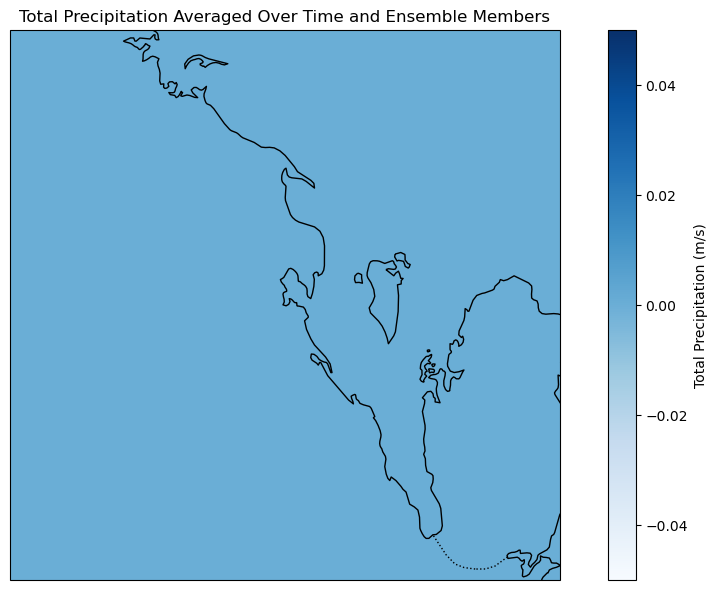

In [125]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
# Load your dataset


#ds = xr.open_dataset("clipped_kenya_tprate.nc")
ecmwf = ecmwf.rio.write_crs("EPSG:4326")  # WGS84

# Use country polygons instead of boundary lines
country_set = "admin_0_countries"
shapefile_path = shpreader.natural_earth(resolution="10m", category="cultural", name=country_set)

# Ensure output directory exists
if not os.path.exists('ecmwf'):
    os.makedirs('ecmwf')

# Copy all related files
for ext in [".shp", ".shx", ".dbf", ".prj", ".cpg"]:
    source_file = str(shapefile_path).replace(".shp", ext)
    shutil.copy(source_file, os.path.join('ecmwf', os.path.basename(source_file)))

# Load country polygons
geodf = gpd.read_file("ecmwf/ne_10m_admin_0_countries.shp")

# Filter for Kenya
kenya_geom = geodf[geodf['ADMIN'] == location]

# Clip using polygon
clipped = ecmwf.rio.clip(kenya_geom.geometry.apply(mapping), kenya_geom.crs, drop=False, invert=False)

ds = clipped
ds = ds.assign_coords(year=ds['time'].dt.year, month=ds['time'].dt.month)
ds = ds


#obs = obs

# Convert 'step' from timedelta to days
step_days = ds['step'] / np.timedelta64(1, 'D')

# Broadcast step_days to match tprate dimensions
step_days_expanded = step_days.broadcast_like(ds['tprate'])


# Calculate total precipitation = tprate * step_days
total_precip = ds['tprate'] * step_days_expanded

# Average over time and ensemble members
avg_precip = total_precip.mean(dim=['time', 'number'])

# Sum over step to get total precipitation per location
spatial_precip = avg_precip.sum(dim='step')
#spatial_precip= spatial_precip  * 86400000



# Plot using PlateCarree projection
plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
spatial_precip.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='Blues', cbar_kwargs={'label': 'Total Precipitation (m/s)'})
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_title("Total Precipitation Averaged Over Time and Ensemble Members")
plt.tight_layout()
plt.show()


In [126]:
import geopandas as gpd
import rioxarray
import cartopy.io.shapereader as shpreader
from shapely.geometry import mapping
import os
import shutil
import xarray as xr

# Load Kenya polygon from Natural Earth shapefile
country_set = "admin_0_countries"
shapefile_path = shpreader.natural_earth(resolution="10m", category="cultural", name=country_set)

# Ensure shapefile components are copied to local directory
if not os.path.exists('ecmwf'):
    os.makedirs('ecmwf')

for ext in [".shp", ".shx", ".dbf", ".prj", ".cpg"]:
    source_file = str(shapefile_path).replace(".shp", ext)
    shutil.copy(source_file, os.path.join('ecmwf', os.path.basename(source_file)))

# Load country polygons and filter for Kenya
geodf = gpd.read_file("ecmwf/ne_10m_admin_0_countries.shp")
kenya_geom = geodf[geodf['ADMIN'] == location]

# Function to clip precipitation data for a given year
def clip_precip_to_kenya(year):
    file_name = f"data_down/chirps-v3.0.{year}.monthly.nc"
    ds = xr.open_dataset(file_name)
    precip = ds['precip'].rio.write_crs("EPSG:4326")
    clipped = precip.rio.clip(kenya_geom.geometry.apply(mapping), kenya_geom.crs, drop=True, invert=False)
    return clipped



This provieds the data as OND average rainfall in mm/day per each lat, lon coordinate


In [127]:

# Define OND months and years of interest
ond_months = [11, 12, 1]
years = range(1993, 2017)

# Dictionary to store average daily precipitation maps for OND per year
average_daily_precip_maps = {}

for year in years:
    print(f"Processing {year}...")
    #clipped = clip_precip_to_kenya(year)  # Use your clipping function
    #clipped = kenya_data
    clipped = clip_precip_to_kenya(year)
    
    # Select OND months
    ond_data = clipped.sel(time=clipped.time.dt.month.isin(ond_months))

    def nan_sum_with_nan_if_all_nan(x, dim):
        return xr.where(x.isnull().all(dim), np.nan, x.sum(dim=dim, skipna=True))
    
    # Calculate total precipitation over OND (sum over time)
    #total_precip = ond_data.sum(dim='time') # need to put ['precip'] after ond_data when using kenya_data
    total_precip = nan_sum_with_nan_if_all_nan(ond_data, dim='time')
    
    # Calculate average daily precipitation (assuming 92 days in OND)
    avg_daily_precip = total_precip / 92
    
    # Store the result for this year
    average_daily_precip_maps[year] = avg_daily_precip

# Example: print the average daily precipitation map for 1993
print("OND average daily precipitation (mm/day) for 1993:")
print(average_daily_precip_maps[1993])


Processing 1993...
Processing 1994...
Processing 1995...
Processing 1996...
Processing 1997...
Processing 1998...
Processing 1999...
Processing 2000...
Processing 2001...
Processing 2002...
Processing 2003...
Processing 2004...
Processing 2005...
Processing 2006...
Processing 2007...
Processing 2008...
Processing 2009...
Processing 2010...
Processing 2011...
Processing 2012...
Processing 2013...
Processing 2014...
Processing 2015...
Processing 2016...
OND average daily precipitation (mm/day) for 1993:
<xarray.DataArray 'precip' (latitude: 10, longitude: 5)> Size: 200B
array([[       nan,        nan, 0.51600343,        nan,        nan],
       [       nan,        nan, 0.50391996,        nan,        nan],
       [       nan, 0.57504267, 0.5674433 ,        nan,        nan],
       [0.591635  , 0.5123431 , 0.5157974 ,        nan,        nan],
       [       nan, 0.5637892 , 0.5652295 ,        nan,        nan],
       [       nan, 0.66910744, 0.6115494 ,        nan,        nan],
       [0.6

In [128]:
import xarray as xr

# Combine all yearly precipitation maps into a single xarray DataArray
# average_daily_precip_maps should be a dictionary like {1993: DataArray, ..., 2016: DataArray}
all_years_data = xr.concat(list(average_daily_precip_maps.values()), dim='year')

# Compute the mean across the 'year' dimension
mean_precip_all_years = all_years_data.mean(dim='year')

# Print or save the result
print("Average OND precipitation (mm/day) across all years for each grid cell:")
print(mean_precip_all_years)


Average OND precipitation (mm/day) across all years for each grid cell:
<xarray.DataArray 'precip' (latitude: 10, longitude: 5)> Size: 200B
array([[       nan,        nan, 0.4368347 ,        nan,        nan],
       [       nan,        nan, 0.43007624,        nan,        nan],
       [       nan, 0.4618142 , 0.44607702,        nan,        nan],
       [0.45709217, 0.43790492, 0.43286368,        nan,        nan],
       [       nan, 0.45149305, 0.46156612,        nan,        nan],
       [       nan, 0.4748731 , 0.46766683,        nan,        nan],
       [0.46667555, 0.46800014, 0.4868721 , 0.4923489 ,        nan],
       [0.47930703, 0.47388342, 0.47834888,        nan,        nan],
       [0.46909   , 0.47318015, 0.48842657,        nan, 0.49156466],
       [       nan,        nan,        nan, 0.53087646,        nan]],
      dtype=float32)
Coordinates:
  * latitude     (latitude) float32 40B 25.82 25.88 25.92 ... 26.17 26.22 26.27
  * longitude    (longitude) float32 20B 50.47 50.52 50

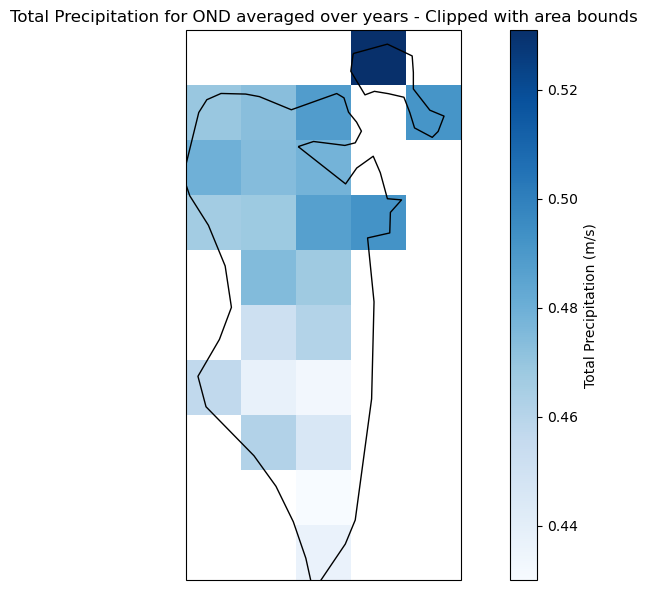

In [129]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
# Plot using PlateCarree projection
plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
mean_precip_all_years.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='Blues', cbar_kwargs={'label': 'Total Precipitation (m/s)'})
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_title("Total Precipitation for OND averaged over years - Clipped with area bounds")
plt.tight_layout()
plt.show()

# import xarray as xr
# import numpy as np
# import matplotlib.pyplot as plt
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature

# # Define Kenya's geographic bounds
# kenya_bounds = {
#     'lat_min': -10,
#     'lat_max': 25.0,
#     'lon_min': 20,
#     'lon_max': 40.0
# }

# # Clip the dataset to Kenya's bounds
# mean_precip_kenya = mean_precip_all_years.sel(
#     latitude=slice(kenya_bounds['lat_min'], kenya_bounds['lat_max']),
#     longitude=slice(kenya_bounds['lon_min'], kenya_bounds['lon_max'])
# )

# # Plot using PlateCarree projection
# plt.figure(figsize=(10, 6))
# ax = plt.axes(projection=ccrs.PlateCarree())
# mean_precip_kenya.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='Blues', cbar_kwargs={'label': 'Total Precipitation (m/s)'})
# ax.coastlines()
# ax.add_feature(cfeature.BORDERS, linestyle=':')
# ax.set_extent([kenya_bounds['lon_min'], kenya_bounds['lon_max'], kenya_bounds['lat_min'], kenya_bounds['lat_max']], crs=ccrs.PlateCarree())
# ax.set_title("Total Precipitation for OND averaged over years - Kenya")
# plt.tight_layout()
# plt.show()


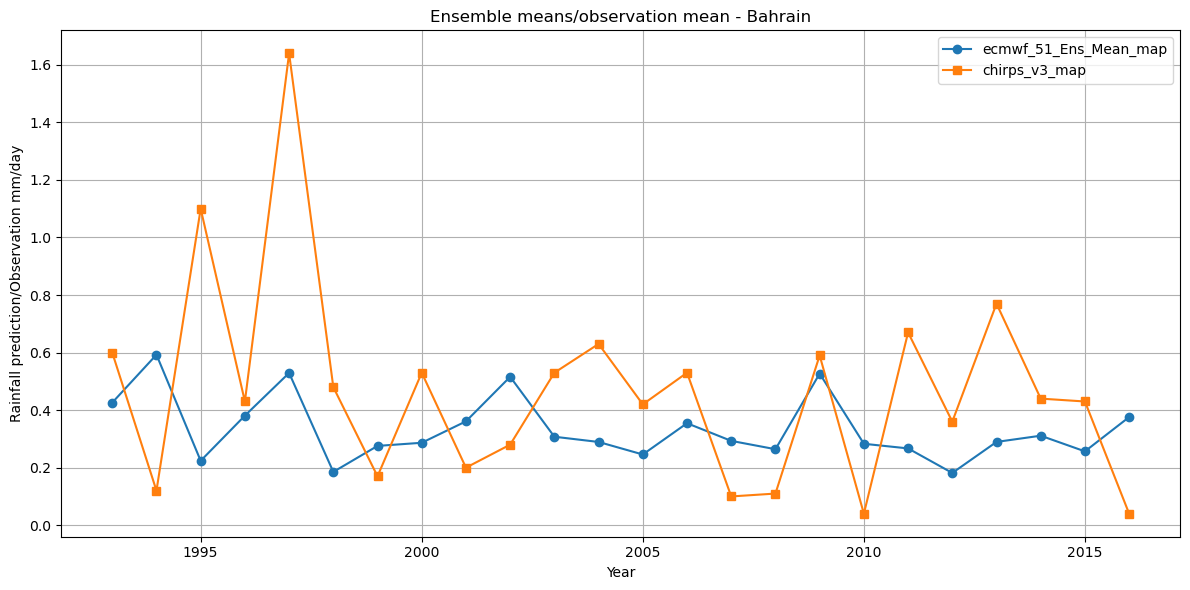

In [130]:
import matplotlib.pyplot as plt

# Years from 1993 to 2016
years = list(range(1993, 2017))
years2 = list(range(1993, 2017))

Chirps3 = [1.68, 3.1, 2.04, 1.54, 5.85, 1.23, 2.17, 2.09, 2.04, 2.91, 1.92, 2.3, 1.1, 4.4, 1.75, 1.8, 2.57, 1.48, 3.68, 2.64, 2.07, 2.15, 3.09, 1.72]
Chirps_with_0 = [1.04, 1.92, 1.26, 0.95, 3.63, 0.76, 1.34, 1.3, 1.27, 1.8, 1.19, 1.43, 0.68, 2.73, 1.08, 1.12, 1.59, 0.92, 2.28, 1.64, 1.28, 1.34, 1.92, 1.06]
#ensemble_mean_1

Obs_Rain =  [1.52,2.93,1.95,1.51,5.56,1.33,2.04,2.34,1.99,2.95,1.90,2.40,1.15,4.31,1.83,1.98,2.65,1.55,3.86,2.72,2.25,2.31,3.13,1.70]
# Plotting both datasets
plt.figure(figsize=(12, 6))
plt.plot(years, ensemble_mean_1['tprate'], marker='o', label='ecmwf_51_Ens_Mean_map')
#plt.plot(years, enm, marker='o', label='ecmwf_51_Ens_Mean_map')
#plt.plot(years, excell_mean_member, marker='s', label='XEL')
#plt.plot(years, Obs_Rain, marker='s', label='Obs-excell')
#plt.plot(years, filtered_obs['tp'], marker = 's', label = 'era5')
plt.plot(years2, precip_values, marker = 's', label = 'chirps_v3_map')
#plt.plot(years2, Chirps3, marker = 's', label = 'chirps_with_nan')
#plt.plot(years2, Chirps_with_0, marker = 's', label = 'chirps_with_0')



# Adding labels and title
plt.xlabel('Year')
plt.ylabel('Rainfall prediction/Observation mm/day')
plt.title(f'Ensemble means/observation mean - {location}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [117]:
enm=[0.076534,
0.075933,
0.061669,
0.077645,
0.099259,
0.048822,
0.046464,
0.064946,
0.073760,
0.112235,
0.073852,
0.077895,
0.050500,
0.066454,
0.065101,
0.064962,
0.073745,
0.051742,
0.053989,
0.072915,
0.062251,
0.082820,
0.072083,
0.070149,]